In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [19]:
startup_data = pd.read_csv('Data/50_Startups.csv')
startup_data.info()
startup_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [13]:
x = startup_data.iloc[:,:-1].values
y = startup_data.iloc[:,-1].values

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(),[3])], remainder='passthrough')
x = np.array(ct.fit_transform(x))

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=67)

In [21]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
model.coef_
model.intercept_

np.float64(50880.96064230801)

In [22]:
y_predict = model.predict(x_test)

In [28]:
print(y_predict)
print(y_test)

[158958.15826186 186811.60939222 113608.75503164 147756.2571802
 134222.92266319  73106.00702021  71756.56346882  98658.74105722
  44529.23935129 114313.75477659]
[156122.51 191792.06 118474.03 129917.04 144259.4   90708.19  78239.91
  97427.84  42559.73 126992.93]


<Axes: >

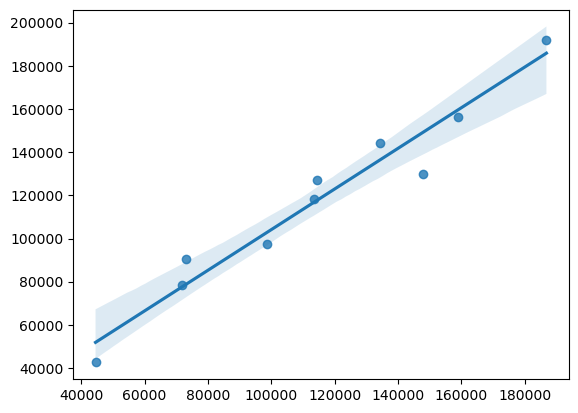

In [25]:
sns.regplot(x=y_predict, y=y_test)

In [26]:
from sklearn import metrics
print(f'R² = {metrics.r2_score(y_test, y_predict)}')

R² = 0.9388615482484188
